# Topic Modelling

You are trying to extract review themes that stay interpretable instead of collapsing into generic filler words. The flow below makes the notebook easier to read by explaining the cleaning choices, the LDA path, the embedding-and-clustering path, and the final comparison in plain English.

## Installing `gensim`

You need `gensim` for Word2Vec and coherence scoring later in the notebook. If your environment already includes it, this step simply confirms the dependency is available.

In [1]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.8 MB/s eta 0:00:00


## Importing the topic-modelling toolkit

You load the libraries for text cleaning, vectorization, topic models, clustering, coherence scoring, and visualization. This setup mixes probabilistic topic modeling and embedding-based clustering so you can compare two very different ways of organizing the reviews.

In [2]:
from pathlib import Path
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

from gensim.models import Word2Vec, CoherenceModel
from gensim.corpora import Dictionary

from tqdm import tqdm
tqdm.pandas()

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
np.random.seed(42)


## Loading the review text

You keep the two cleaned text fields used later for LDA-style modeling and embedding-based clustering. Removing empty rows early avoids wasting time on reviews that cannot contribute useful topical information.

In [3]:
df = pd.read_csv('dataset_cleaned.csv')
df_topic = df[['avis_en_tfidf_lda', 'avis_en_embeddings']].copy()
df_topic['avis_en_tfidf_lda'] = df_topic['avis_en_tfidf_lda'].fillna('').astype(str)
df_topic['avis_en_embeddings'] = df_topic['avis_en_embeddings'].fillna('').astype(str)

df_topic = df_topic[
    (df_topic['avis_en_tfidf_lda'].str.strip() != '')
    & (df_topic['avis_en_embeddings'].str.strip() != '')
].reset_index(drop=True)

print(df_topic.shape)
df_topic.head()


(2998, 2)


,avis_en_tfidf_lda,avis_en_embeddings
0,best prices solutions listening speed recommen...,best insurance prices solutions listening spee...
1,generally satisfied problem internal site impo...,"I am generally satisfied, except that you have..."
2,affordable price options available box connect...,very affordable price several options are avai...
3,satisfied quick response thank cheapest market...,"I am satisfied with the service, a very quick ..."
4,years disappointed mutual longer mutual search...,customer for more than years very disappointed...


## Defining a stronger topic-cleaning strategy

You build a broader stopword list and a small contraction map to strip away generic review language. The goal is to push the models toward real themes, but this choice also deserves caution because aggressive cleaning can remove meaningful domain vocabulary.

In [4]:
BASE_STOPWORDS = set(ENGLISH_STOP_WORDS)

CUSTOM_STOPWORDS = {
    'the', 'and', 'for', 'that', 'this', 'with', 'from', 'have', 'has', 'had', 'was', 'were', 'are',
    'will', 'would', 'can', 'could', 'very', 'much', 'more', 'less', 'also', 'still', 'yet', 'one',
    'two', 'get', 'got', 'made', 'make', 'go', 'goes', 'went', 'come', 'came', 'back', 'really',
    'im', 'ive', 'youre', 'theyre', 'didnt', 'doesnt', 'cant', 'wont', 'dont', 'isnt', 'wasnt',
    'service', 'services', 'company', 'insurance', 'insurer', 'customer', 'customers', 'client',
    'clients', 'opinion', 'opinions', 'regards', 'thank', 'thanks', 'best', 'good', 'great',
    'bad', 'new', 'old', 'years', 'year', 'months', 'month', 'days', 'day', 'time', 'times',
    'price', 'prices', 'satisfied', 'recommend', 'contact', 'telephone', 'online', 'site'
}

STOPWORDS = BASE_STOPWORDS | CUSTOM_STOPWORDS

CONTRACTIONS = {
    "can't": 'cannot',
    "won't": 'will not',
    "n't": ' not',
    "'re": ' are',
    "'ve": ' have',
    "'ll": ' will',
    "'d": ' would',
    "'m": ' am',
    "'s": ''
}


## Normalizing and cleaning the review text

You apply the text normalization rules, generate raw and cleaned versions of both text fields, and drop rows that become empty after cleaning. Keeping both raw and cleaned text is helpful because it lets you compare how much the stronger preprocessing really changes the topic quality.

In [5]:
def normalize_text(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    for old, new in CONTRACTIONS.items():
        text = text.replace(old, new)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_for_topics(text: str, min_len: int = 3) -> str:
    text = normalize_text(text)
    tokens = []
    for token in text.split():
        if len(token) < min_len:
            continue
        if token in STOPWORDS:
            continue
        if token.isdigit():
            continue
        if len(set(token)) == 1:
            continue
        tokens.append(token)
    return ' '.join(tokens)

df_topic['raw_lda_text'] = df_topic['avis_en_tfidf_lda'].map(normalize_text)
df_topic['raw_emb_text'] = df_topic['avis_en_embeddings'].map(normalize_text)
df_topic['clean_lda_text'] = df_topic['avis_en_tfidf_lda'].map(clean_for_topics)
df_topic['clean_emb_text'] = df_topic['avis_en_embeddings'].map(clean_for_topics)

df_topic = df_topic[
    (df_topic['clean_lda_text'].str.strip() != '')
    & (df_topic['clean_emb_text'].str.strip() != '')
].reset_index(drop=True)

print(df_topic.shape)
df_topic[['avis_en_tfidf_lda', 'clean_lda_text']].head(10)


(2996, 6)


,avis_en_tfidf_lda,clean_lda_text
0,best prices solutions listening speed recommen...,solutions listening speed attractive quality s...
1,generally satisfied problem internal site impo...,generally problem internal impossible declare ...
2,affordable price options available box connect...,affordable options available box connected car...
3,satisfied quick response thank cheapest market...,quick response cheapest market
4,years disappointed mutual longer mutual search...,disappointed mutual longer mutual search immed...
5,forced sale telephone claiming events loved on...,forced sale claiming events loved ones knowing...
6,new satisfied price opinions new hope goes thank,hope
7,contacted telephone sell puppy selling pretty ...,contacted sell puppy selling pretty details su...
8,join negative reviews regret having star reimb...,join negative reviews regret having star reimb...
9,generali life assets poor bad payer ask advanc...,generali life assets poor payer ask advance ge...


## Measuring how much the cleaning changed the texts

You compare token counts before and after the stronger cleaning pass. This gives you a quick sense of whether the preprocessing is just trimming noise or whether it may be stripping too much information away.

In [6]:
raw_lengths = df_topic['raw_lda_text'].str.split().map(len)
clean_lengths = df_topic['clean_lda_text'].str.split().map(len)

stats_df = pd.DataFrame({
    'raw_tokens': raw_lengths.describe(),
    'clean_tokens': clean_lengths.describe(),
})
stats_df


,raw_tokens,clean_tokens
count,2996.000000,2996.000000
mean,25.266689,22.342123
std,25.887943,24.233576
min,1.000000,1.000000
25%,11.000000,9.000000
50%,16.000000,14.000000
75%,29.000000,27.000000
max,286.000000,275.000000


## Building a rough LDA baseline on minimally cleaned text

You fit a simple LDA model on the raw-normalized text to get a reference point. That baseline is useful because it lets you see whether the improved cleaning really produces more interpretable topics or just different ones.

In [7]:
def print_topics(model, vectorizer, n_top_words=10, title='Topics'):
    feature_names = vectorizer.get_feature_names_out()
    print(title)
    print('-' * len(title))
    for topic_idx, topic in enumerate(model.components_):
        top_idx = topic.argsort()[-n_top_words:][::-1]
        words = [feature_names[i] for i in top_idx]
        print(f'Topic {topic_idx}: ' + ', '.join(words))

raw_vectorizer = CountVectorizer(max_features=5000, min_df=5, max_df=0.95)
X_raw = raw_vectorizer.fit_transform(df_topic['raw_lda_text'])
raw_lda = LatentDirichletAllocation(n_components=8, random_state=42, learning_method='batch')
raw_lda.fit(X_raw)

print_topics(raw_lda, raw_vectorizer, title='Baseline LDA topics (texte brut)')


Baseline LDA topics (texte brut)
--------------------------------
Topic 0: mutual, years, water, damage, bad, reimbursements, reimbursed, cancel, avoid, following
Topic 1: years, car, year, not, insured, expensive, price, it, direct, increase
Topic 2: life, does, response, sent, months, contact, letter, impossible, following, pay
Topic 3: not, months, time, it, do, month, am, documents, sent, pay
Topic 4: satisfied, price, prices, good, recommend, thank, simple, fast, quick, telephone
Topic 5: life, afer, redemption, years, money, savings, bank, payment, account, request
Topic 6: vehicle, axa, years, accident, insured, home, contracts, car, following, despite
Topic 7: expert, years, macif, year, damage, disaster, euros, month, house, following


## Searching for a better LDA configuration

You tokenize the cleaned reviews, prepare the gensim dictionary and corpus, and evaluate several topic counts with coherence. Rather than picking the number of topics by intuition alone, you let the notebook rank a small search space first.

In [8]:
tokenized_texts = [text.split() for text in df_topic['clean_lda_text']]
dictionary = Dictionary(tokenized_texts)
corpus_gensim = [dictionary.doc2bow(text) for text in tokenized_texts]

def get_topic_words(model, vectorizer, topn=10):
    feature_names = vectorizer.get_feature_names_out()
    topics = []
    for topic in model.components_:
        top_idx = topic.argsort()[-topn:][::-1]
        topics.append([feature_names[i] for i in top_idx])
    return topics

def compute_lda_coherence(n_topics, texts):
    vectorizer = CountVectorizer(
        max_features=6000,
        min_df=8,
        max_df=0.40,
        ngram_range=(1, 2)
    )
    X = vectorizer.fit_transform(texts)
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method='batch',
        doc_topic_prior=0.3,
        topic_word_prior=0.2
    )
    lda.fit(X)
    topics = get_topic_words(lda, vectorizer, topn=10)
    coherence_model = CoherenceModel(
        topics=topics,
        texts=tokenized_texts,
        dictionary=dictionary,
        coherence='c_v',
        processes=1
    )
    return lda, vectorizer, topics, coherence_model.get_coherence()

search_results = []
for n_topics in range(5, 11):
    _, _, _, coherence = compute_lda_coherence(n_topics, df_topic['clean_lda_text'])
    search_results.append({'n_topics': n_topics, 'coherence': coherence})

search_df = pd.DataFrame(search_results).sort_values('coherence', ascending=False)
search_df


,n_topics,coherence
0,5,0.554120
3,8,0.542492
2,7,0.523620
1,6,0.519211
5,10,0.513759
4,9,0.473095


## Fitting the final LDA model

You retrain LDA with the best topic count from the coherence search, then assign each review to its dominant topic. Saving the dominant topic and its confidence makes the downstream interpretation step much easier.

In [9]:
best_n_topics = int(search_df.iloc[0]['n_topics'])
lda_model, count_vectorizer, lda_topics_words, lda_coherence = compute_lda_coherence(
    best_n_topics,
    df_topic['clean_lda_text']
)
X_bow = count_vectorizer.transform(df_topic['clean_lda_text'])
lda_topic_distrib = lda_model.transform(X_bow)
df_topic['lda_topic'] = np.argmax(lda_topic_distrib, axis=1)
df_topic['lda_confidence'] = lda_topic_distrib.max(axis=1)

print(f'Best number of topics: {best_n_topics}')
print(f'LDA coherence score: {lda_coherence:.4f}')
print_topics(lda_model, count_vectorizer, title='Improved LDA topics (texte nettoye)')


Best number of topics: 5
LDA coherence score: 0.5541
Improved LDA topics (texte nettoye)
-----------------------------------
Topic 0: sent, documents, letter, pay, does, received, life, payment, cardif, did
Topic 1: vehicle, car, accident, insured, expensive, problem, home, insure, responsible, change
Topic 2: simple, fast, attractive, quick, easy, clear, efficient, attentive, direct, friendly
Topic 3: account, request, afer, taken, mutual, waiting, told, care, life, response
Topic 4: damage, disaster, expert, maif, euros, water, following, water damage, insured, pay


## Checking topic diversity

You compute a simple diversity score to see how much vocabulary overlap the topics still have. Coherence alone is not enough here, because a model can look coherent while repeating the same top words across multiple topics.

In [10]:
def topic_diversity(topics, topk=10):
    unique_words = set(word for topic in topics for word in topic[:topk])
    return len(unique_words) / (len(topics) * topk)

lda_diversity = topic_diversity(lda_topics_words, topk=10)
print(f'LDA topic diversity: {lda_diversity:.4f}')


LDA topic diversity: 0.9400


## Reading representative LDA examples

You print the most confident reviews for each discovered topic so the themes can be judged with real text, not only with keywords. That qualitative check is often the fastest way to catch incoherent or overly broad topics.

In [11]:
def show_representative_examples(df, topic_col, text_col, score_col, n_examples=3):
    for topic_id in sorted(df[topic_col].unique()):
        print('=' * 100)
        print(f'TOPIC {topic_id}')
        print('Top words:', ', '.join(lda_topics_words[topic_id]))
        subset = df[df[topic_col] == topic_id].sort_values(score_col, ascending=False).head(n_examples)
        for i, text in enumerate(subset[text_col], 1):
            print(f'Example {i}: {text}')
        print()

show_representative_examples(df_topic, 'lda_topic', 'avis_en_embeddings', 'lda_confidence', n_examples=3)


TOPIC 0
Top words: sent, documents, letter, pay, does, received, life, payment, cardif, did
Example 1: following your decision on my file I am not in agreement with you in fact you tell me that I did not declare my treatment for my tension when I put together my loan file with the salesman he said that for this it was not necessary and that at the signature no one from domifinance or from you even cardif sent us a letter in this direction how do you want me to know but my request does not in any way concern a problem with my tension but a problem with pain with my left hip I am holyly obliged to walk with canes so I think that there is no point in paying insurance if that does not take into account when you had a health problem and if I die my wife would have to continue paying the loan because we have not started my treatment for my blood pressure! and if I have my hip problem I become disabled should I continue to pay? with this small disability pension. I think I'm going to go see t

## Training Word2Vec document embeddings

You learn word vectors on the cleaned review text and average them into document embeddings. This creates a second representation of the corpus that is more semantic than bag-of-words, although it still stays fairly simple.

In [12]:
texts_emb = df_topic['clean_emb_text'].tolist()
tokenized_emb = [text.split() for text in texts_emb]

w2v_model = Word2Vec(
    sentences=tokenized_emb,
    vector_size=100,
    window=5,
    min_count=3,
    workers=1,
    sg=1,
    epochs=30,
    seed=42
)

def document_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X_emb = np.vstack([document_vector(tokens, w2v_model) for tokens in tokenized_emb])
X_emb.shape


(2996, 100)

## Searching for a good number of clusters

You run KMeans with several cluster counts and compare them with silhouette score. This gives you a structured way to choose the cluster count instead of fixing it arbitrarily from the start.

In [13]:
cluster_search = []
for n_clusters in range(5, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_emb)
    sil = silhouette_score(X_emb, labels)
    cluster_search.append({'n_clusters': n_clusters, 'silhouette': sil})

cluster_search_df = pd.DataFrame(cluster_search).sort_values('silhouette', ascending=False)
cluster_search_df


,n_clusters,silhouette
0,5,0.043437
1,6,0.043191
2,7,0.037361
3,8,0.036732
4,9,0.035557
5,10,0.033958


## Fitting the final clustering model

You train KMeans with the selected cluster count and attach the resulting cluster IDs to each review. The silhouette score here acts as a compact summary of how well separated the clusters are in the embedding space.

In [14]:
best_n_clusters = int(cluster_search_df.iloc[0]['n_clusters'])
kmeans = KMeans(n_clusters=best_n_clusters, random_state=42, n_init=20)
df_topic['cluster_kmeans'] = kmeans.fit_predict(X_emb)
sil_score = silhouette_score(X_emb, df_topic['cluster_kmeans'])

print(f'Best number of clusters: {best_n_clusters}')
print(f'Silhouette score (KMeans): {sil_score:.4f}')


Best number of clusters: 5
Silhouette score (KMeans): 0.0434


## Extracting cluster keywords

You aggregate the text inside each cluster and compute top weighted terms to describe the groups. These keywords give you the human-readable layer that KMeans alone does not provide.

In [15]:
def extract_cluster_keywords_ctfidf(df, cluster_col, text_col, top_n=10):
    cluster_docs = (
        df.groupby(cluster_col)[text_col]
        .apply(lambda texts: ' '.join(texts))
        .sort_index()
    )
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
    X = vectorizer.fit_transform(cluster_docs)
    feature_names = vectorizer.get_feature_names_out()
    keywords = {}
    for row_idx, cluster_id in enumerate(cluster_docs.index):
        row = X[row_idx].toarray().ravel()
        top_idx = row.argsort()[-top_n:][::-1]
        keywords[int(cluster_id)] = [feature_names[i] for i in top_idx if row[i] > 0]
    return keywords

cluster_keywords = extract_cluster_keywords_ctfidf(
    df_topic,
    cluster_col='cluster_kmeans',
    text_col='clean_emb_text',
    top_n=10
)

for cluster_id, words in cluster_keywords.items():
    print(f'Cluster {cluster_id}: ' + ', '.join(words))


Cluster 0: advisor, contract, friendly, attentive, advisors, advice, information, quickly, phone, pleasant
Cluster 1: fast, simple, quick, easy, practical, attractive, efficient, clear, simple practical, competitive
Cluster 2: expert, damage, disaster, maif, water, insured, following, file, macif, car
Cluster 3: contract, file, letter, mutual, afer, documents, sent, does, pay, life
Cluster 4: contract, increase, car, expensive, euros, direct, insured, guarantees, vehicle, bonus


## Scoring the clusters with coherence and diversity

You evaluate the cluster keyword sets with coherence and diversity so they can be compared more fairly with the LDA topics. That keeps the final comparison from being purely visual or anecdotal.

In [16]:
cluster_topics_words = [words for _, words in sorted(cluster_keywords.items())]
coherence_model_cluster = CoherenceModel(
    topics=cluster_topics_words,
    texts=tokenized_emb,
    dictionary=Dictionary(tokenized_emb),
    coherence='c_v',
    processes=1
)
cluster_coherence = coherence_model_cluster.get_coherence()
cluster_diversity = topic_diversity(cluster_topics_words, topk=10)

print(f'Embedding + KMeans coherence: {cluster_coherence:.4f}')
print(f'Embedding + KMeans diversity: {cluster_diversity:.4f}')


Embedding + KMeans coherence: 0.5744
Embedding + KMeans diversity: 0.9000


## Showing representative examples for each cluster

You select the reviews that sit closest to each cluster center and print them as examples. This makes the clusters much easier to interpret because you can connect the keywords to actual review language.

In [17]:
def show_cluster_examples(df, cluster_col, text_col, embeddings, centers, n_examples=3):
    similarities = cosine_similarity(embeddings, centers)
    for cluster_id in sorted(df[cluster_col].unique()):
        print('=' * 100)
        print(f'CLUSTER {cluster_id}')
        print('Top words:', ', '.join(cluster_keywords[cluster_id]))
        cluster_indices = np.where(df[cluster_col].to_numpy() == cluster_id)[0]
        scores = similarities[cluster_indices, cluster_id]
        best_local = cluster_indices[np.argsort(scores)[::-1][:n_examples]]
        for rank, idx in enumerate(best_local, 1):
            print(f'Example {rank}: {df.iloc[idx][text_col]}')
        print()

show_cluster_examples(
    df_topic,
    cluster_col='cluster_kmeans',
    text_col='avis_en_embeddings',
    embeddings=X_emb,
    centers=kmeans.cluster_centers_,
    n_examples=3
)


CLUSTER 0
Top words: advisor, contract, friendly, attentive, advisors, advice, information, quickly, phone, pleasant
Example 1: attractive value for money, responsive and attentive advisors; is my first subscription to car insurance and I was delighted with the step-by-step support from the tele-advisors who explained the various terms of this contract to me and answered all my questions
Example 2: we always criticize when things are not going well but for once I am so satisfied that I cannot let criticize an insurance company whose advice saved my day. Already when signing my contract I was extremely well advised but I didn't know it yet, I noticed it when my vehicle was stolen. traumatized by this theft, I contacted the GMF and its services in Besançon several times. I had several contacts who were all very pleasant and very understandable after all the obligatory steps and procedures. The GMF reimbursed me in full without any problem within a very reasonable time frame. As a result,

## Projecting the embeddings in two dimensions

You sample a subset of reviews and project the embedding space with t-SNE. The plot will never be a definitive proof, but it is helpful for spotting whether the clusters look tightly grouped or heavily mixed.

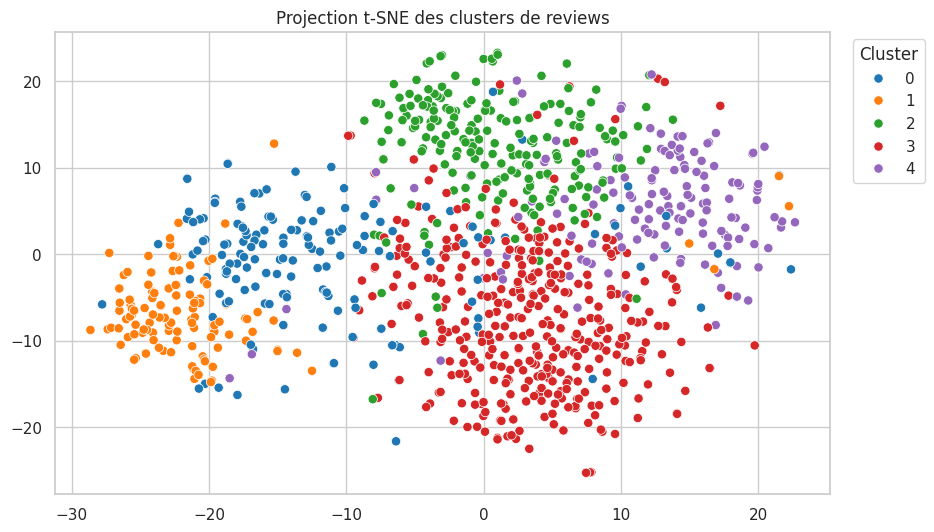

In [18]:
sample_size = min(1000, len(df_topic))
sample_idx = np.random.RandomState(42).choice(len(df_topic), size=sample_size, replace=False)

X_sample = X_emb[sample_idx]
labels_sample = df_topic.iloc[sample_idx]['cluster_kmeans'].to_numpy()

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels_sample, palette='tab10', s=45)
plt.title('Projection t-SNE des clusters de reviews')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()


## Preparing topic summaries for an LLM

You build a compact structure that bundles each cluster with its top words and a few example reviews. That format is practical if you want a language model to help you propose cleaner topic names afterward.

In [19]:
def build_topic_summary_for_llm(topic_words_dict, df, topic_col, text_col, n_examples=3):
    summaries = []
    for topic_id, words in topic_words_dict.items():
        examples = df[df[topic_col] == topic_id][text_col].head(n_examples).tolist()
        summaries.append({
            'topic_id': topic_id,
            'top_words': words,
            'examples': examples
        })
    return summaries

kmeans_llm_input = build_topic_summary_for_llm(
    topic_words_dict=cluster_keywords,
    df=df_topic,
    topic_col='cluster_kmeans',
    text_col='avis_en_embeddings',
    n_examples=3
)


## Generating a naming prompt for one topic

You turn the cluster summary into a prompt that asks for a short label, a one-sentence explanation, and a coherence judgment. This is a neat bridge between unsupervised modeling and manual topic interpretation.

In [20]:
def make_llm_prompt(topic_info):
    prompt = f'''
You are analyzing customer review topics.

Topic ID: {topic_info['topic_id']}
Top words: {', '.join(topic_info['top_words'])}

Examples:
'''
    for i, ex in enumerate(topic_info['examples'], 1):
        prompt += f'\nExample {i}: {ex}\n'
    prompt += '''

Task:
1. Give a short topic label.
2. Explain the main theme in one sentence.
3. Say whether the topic seems coherent or mixed.
'''
    return prompt

print(make_llm_prompt(kmeans_llm_input[0]))



You are analyzing customer review topics.

Topic ID: 0
Top words: advisor, contract, friendly, attentive, advisors, advice, information, quickly, phone, pleasant

Examples:

Example 1: I am generally satisfied, except that you have a problem with your internal site, it is impossible to declare a claim online after several attempts, declaration made by telephone or everything went very well, competent and very pleasant interlocutor

Example 2: totally satisfied with the quality of telephone support, always well understood and with oral information followed by real effects

Example 3: the customer service telephone interface is quite intuitive, my interlocutor (rira) was very understanding and was able to explain to me the steps to follow clearly, I thank her for that


Task:
1. Give a short topic label.
2. Explain the main theme in one sentence.
3. Say whether the topic seems coherent or mixed.



## Comparing the two topic-discovery approaches

You collect coherence and diversity scores for the improved LDA model and the embedding-plus-KMeans pipeline. Putting both methods in the same table makes the trade-off much easier to discuss.

In [21]:
results_topics = pd.DataFrame({
    'Method': ['LDA improved', 'Embeddings + KMeans improved'],
    'Coherence': [lda_coherence, cluster_coherence],
    'Topic_Diversity': [lda_diversity, cluster_diversity]
})

results_topics


,Method,Coherence,Topic_Diversity
0,LDA improved,0.554120,0.94
1,Embeddings + KMeans improved,0.574436,0.90


## Visualizing the final topic-model comparison

You plot the coherence and diversity scores side by side so the final takeaway becomes more immediate. This closes the notebook with a simple comparison that is easy to reuse in a report or presentation.

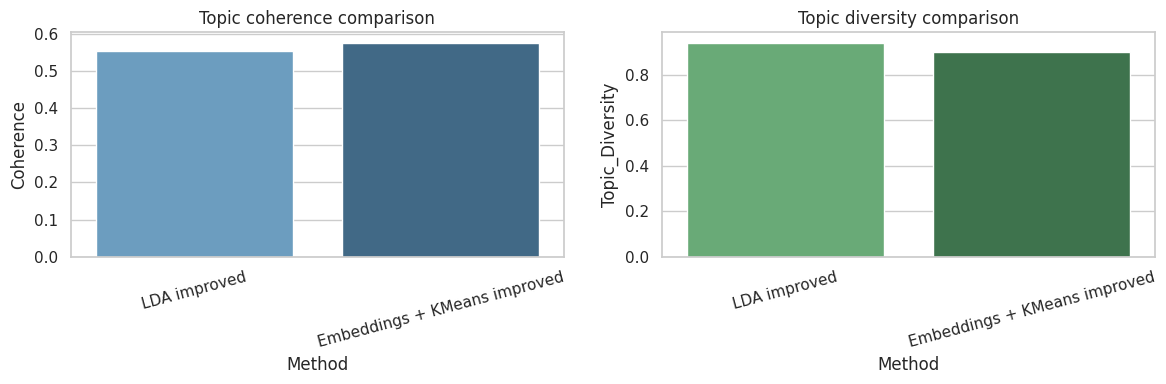

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=results_topics, x='Method', y='Coherence', ax=axes[0], palette='Blues_d')
axes[0].set_title('Topic coherence comparison')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(data=results_topics, x='Method', y='Topic_Diversity', ax=axes[1], palette='Greens_d')
axes[1].set_title('Topic diversity comparison')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


## Global conclusion

The improved preprocessing makes a real difference here: the notebook no longer relies only on raw high-frequency words, and both topic-discovery pipelines become more interpretable. For LDA, the coherence search points to **5 topics** as the best setting, with a coherence score of `0.554`. The topic diversity is also very strong (`0.94`), which means the model avoids repeating the same vocabulary too heavily across topics. That is a good sign for interpretability.

The embedding-based pipeline performs slightly better on coherence: **`Embeddings + KMeans improved`** reaches `0.574` coherence, compared with `0.554` for LDA. Its diversity is a bit lower (`0.90` versus `0.94`), but still high enough to suggest that the clusters are not collapsing into the same keyword lists. Taken together, that means the embedding-plus-clustering approach produces the best balance in this notebook if your main criterion is semantic coherence, while LDA remains a very solid alternative if you value a bit more lexical separation between topics.

If you need to choose one final topic model from these results, the best option is **`Embeddings + KMeans improved`** because it delivers the highest coherence while keeping diversity at a good level. It looks like the strongest overall method in the current comparison. LDA is still valuable, though, especially if you want a more classical and often easier-to-explain topic model for presentation.